In [ ]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

In [ ]:
cifar10 = keras.datasets.cifar10
(x_train,y_train),(x_test,y_test) = cifar10.load_data()
x_train,y_test = x_train/255.0 , x_test/255.0

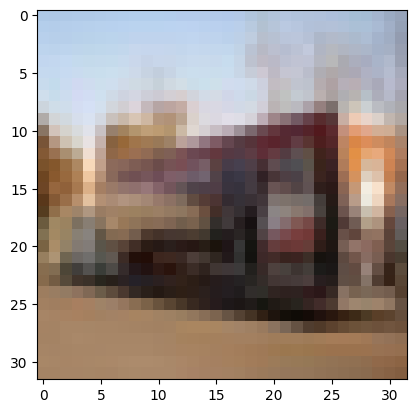

In [ ]:
import matplotlib.pyplot as plt
plt.imshow(x_train[2547])

In [ ]:
x_train.shape

(50000, 32, 32, 3)

In [ ]:
y_train[2547]

array([9], dtype=uint8)

In [ ]:
from tensorflow.keras import layers
from tensorflow.keras import models
model = models.Sequential()
model.add(layers.Conv2D(32,(3,3),activation='relu',input_shape=(32,32,3)))
model.add(layers.MaxPooling2D((2,2)))
model.add(layers.Conv2D(64,(3,3),activation='relu'))
model.add(layers.MaxPooling2D((2,2)))
model.add(layers.Conv2D(64,(3,3),activation='relu'))

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [ ]:
model.add(layers.Flatten())
model.add(layers.Dense(64,activation='relu'))
model.add(layers.Dense(10))

In [ ]:
model.summary()

Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_3 (Conv2D)               │ (None, 30, 30, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 15, 15, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 13, 13, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 6, 6, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 4, 4, 64)       │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_3 (Flatten)             │ (None, 1024)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 64)             │        65,600 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 122,570 (478.79 KB)

 Trainable params: 122,570 (478.79 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
model.compile(optimizer='adam',
              loss =tf.keras.losses.SparseCategoricalCrossentropy(from_logits = True),
              metrics=['accuracy']
)

In [ ]:
he=model.fit(x_train,y_train,validation_split = 0.2,epochs=6)

Epoch 1/6
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 61s 47ms/step - accuracy: 0.4255 - loss: 1.5746 - val_accuracy: 0.5238 - val_loss: 1.3362
Epoch 2/6
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 81s 47ms/step - accuracy: 0.5641 - loss: 1.2302 - val_accuracy: 0.5890 - val_loss: 1.1669
Epoch 3/6
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 80s 45ms/step - accuracy: 0.6172 - loss: 1.0889 - val_accuracy: 0.6302 - val_loss: 1.0529
Epoch 4/6
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 57s 45ms/step - accuracy: 0.6470 - loss: 0.9997 - val_accuracy: 0.6250 - val_loss: 1.0850
Epoch 5/6
 876/1250 ━━━━━━━━━━━━━━━━━━━━ 16s 43ms/step - accuracy: 0.6776 - loss: 0.9269

In [ ]:
y_pred = model.predict(x_test)

In [ ]:
y_pred[2547]

In [ ]:
plt.plot(he.history['accuracy'])
plt.plot(he.history['val_accuracy'])
plt.title('model_accuracy')
plt.xlabel('epoch')
plt.ylabel('accuracy')
plt.legend(['training_data','validation_data'],loc= 'lower right')

In [ ]:
plt.plot(he.history['loss'])
plt.plot(he.history['val_loss'])
plt.title('model_loss')
plt.xlabel('epoch')
plt.ylabel('loss')
plt.legend(['training_data','validation_data'],loc= 'lower right')